# Dificion del problema: 
Determinar cuál de las dos estrategias de gestión de fatiga —siesta corta o
consumo de café— es más efectiva para mejorar los niveles de alerta y productividad, y cómo
influye la calidad del sueño previo en estos resultados.
## ¿Cómo el análisis de datos podría contribuir a comprender o resolver el problema definido? ¿Qué ideas espera obtener? 

Este análisis proporciona datos cuantitativos que permiten a
estudiantes y profesionales optimizar sus descansos basados en evidencia. Se busca identificar si
existe una correlación directa entre el sueño acumulado y el éxito de la intervención elegida.

In [1]:
import pandas as pd
import numpy as np

# Cargamos el dataset
# Si el archivo está en la misma carpeta, solo necesitas el nombre
df = pd.read_csv('power_nap_vs_coffee_effectiveness_dataset.csv')

# Mostramos las primeras 3 filas para confirmar que cargó bien
df.head(20)

,participant_id,age,occupation,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,alertness_score_before,alertness_score_after,productivity_rating,mood_rating,side_effects
0,1,24,Working Professional,5.4,Power Nap,15,62,77,5,10,Grogginess
1,2,37,Student,5.6,Power Nap,30,67,83,6,5,NaN
2,3,32,Working Professional,4.4,Coffee,30,44,52,2,5,Anxiety
3,4,28,Student,6.9,Coffee,30,59,70,4,6,Crash
4,5,25,Working Professional,4.7,Power Nap,30,40,58,3,6,Grogginess
5,6,38,Freelancer,6.3,Coffee,15,69,84,7,6,NaN
6,7,24,Freelancer,7.4,Coffee,25,60,66,9,2,NaN
7,8,43,Student,4.4,Power Nap,25,59,79,5,10,Grogginess
8,9,36,Student,6.1,Power Nap,25,45,57,6,3,Grogginess
9,10,40,Student,4.9,Coffee,25,61,70,10,6,Crash


In [2]:
print(df.columns)

Index(['participant_id', 'age', 'occupation', 'sleep_hours_previous_night',
       'intervention_type', 'intervention_duration_minutes',
       'alertness_score_before', 'alertness_score_after',
       'productivity_rating', 'mood_rating', 'side_effects'],
      dtype='str')


## Punto 3: Realiza un cálculo de al menos dos medidas estadísticas descriptivas clave (por ejemplo, media, mediana, desviación estándar) utilizando NumPy. ¿Qué información te proporcionan estas medidas sobre los datos? 

In [4]:
# 1. Convertimos a vectores de NumPy
alerta_post = df['alertness_score_after'].values
productividad = df['productivity_rating'].values

# 2. Cálculos
media_alerta = np.mean(alerta_post)
std_alerta = np.std(alerta_post)
mediana_prod = np.median(productividad)

print(f"Media de Alerta Post-Intervención: {media_alerta:.2f}")
print(f"Desviación Estándar de Alerta: {std_alerta:.2f}")
print(f"Mediana de Productividad: {mediana_prod:.2f}")

Media de Alerta Post-Intervención: 71.23
Desviación Estándar de Alerta: 11.41
Mediana de Productividad: 5.00


La media te da el nivel de alerta "esperado" tras el café o la siesta. Una desviación estándar alta indicaría que el efecto es muy diferente entre personas (a algunos les funciona increíble y a otros nada).

## Punto 4. Cree una visualización gráfica adecuada para explorar los datos. Puede ser un histograma, un gráfico de dispersión u otro tipo relevante. Adjunta la visualización y explica cómo esta visualización puede ayudarle a abordar el problema inicial. 


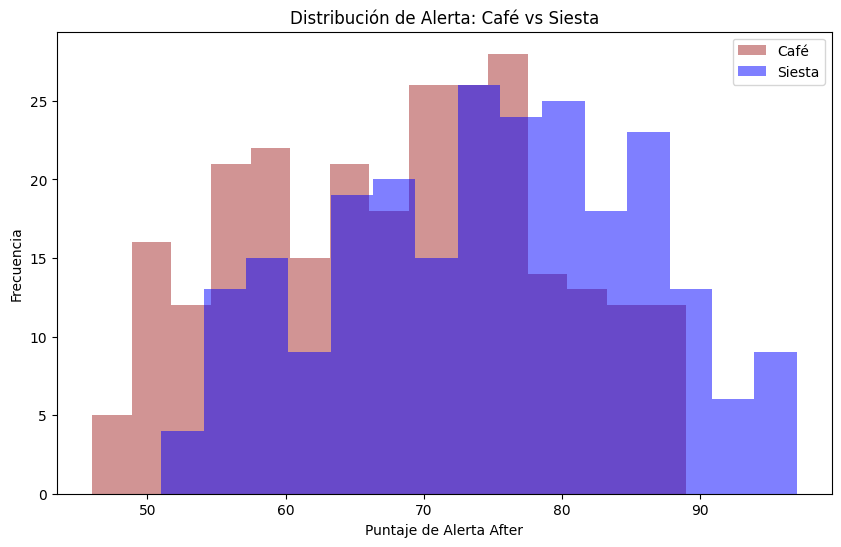

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# Histograma para Café
plt.hist(df[df['intervention_type'] == 'Coffee']['alertness_score_after'], 
         alpha=0.5, label='Café', bins=15, color='brown')
# Histograma para Siesta
plt.hist(df[df['intervention_type'] == 'Power Nap']['alertness_score_after'], 
         alpha=0.5, label='Siesta', bins=15, color='blue')

plt.title('Distribución de Alerta: Café vs Siesta')
plt.xlabel('Puntaje de Alerta After')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

Al analizar el histograma, se observa una tendencia clara: la distribución de la siesta (azul) está sesgada hacia la derecha en comparación con el café, lo que sugiere una mayor efectividad promedio en la alerta post-intervención. Como patrón inicial, notamos que el café presenta una mayor variabilidad en los resultados bajos. Un valor atípico interesante se observa en el rango superior a 95 puntos, alcanzado principalmente por sujetos del grupo de siesta, lo que podría indicar que esta estrategia es más robusta para alcanzar niveles máximos de productividad

## Punt 6. Seleccione dos variables que podrían estar relacionadas dentro del contexto del problema. Convierta las series correspondientes a estas variables en vectores de NumPy e implemente una regresión lineal utilizando numpy.polyfit(). 


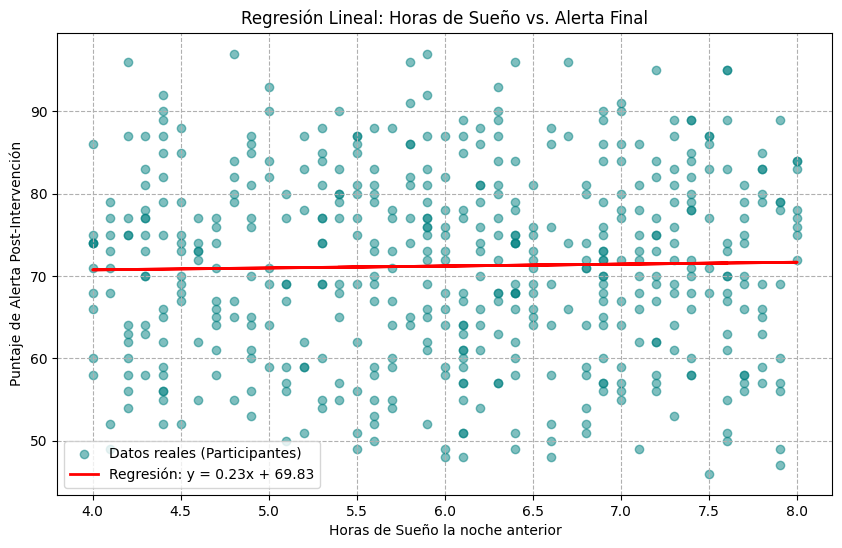

La pendiente (m) es: 0.23
El intercepto (b) es: 69.83


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Seleccionamos las variables y las convertimos a vectores de NumPy (ndarray)
x = df['sleep_hours_previous_night'].values
y = df['alertness_score_after'].values

# 2. Implementamos la regresión lineal usando np.polyfit
# El '1' indica que es un polinomio de primer grado (una línea recta)
coeficientes = np.polyfit(x, y, 1)
m = coeficientes[0] # Pendiente
b = coeficientes[1] # Intercepto

# 3. Creamos la línea de tendencia usando los coeficientes
linea_tendencia = m * x + b

# 4. Graficamos
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, label='Datos reales (Participantes)', color='teal')
plt.plot(x, linea_tendencia, color='red', linewidth=2, label=f'Regresión: y = {m:.2f}x + {b:.2f}')

plt.title('Regresión Lineal: Horas de Sueño vs. Alerta Final')
plt.xlabel('Horas de Sueño la noche anterior')
plt.ylabel('Puntaje de Alerta Post-Intervención')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

print(f"La pendiente (m) es: {m:.2f}")
print(f"El intercepto (b) es: {b:.2f}")

## Punto 8 y 9: 
## Basándote en el gráfico de los datos y la regresión lineal, ¿qué conclusiones puedes extraer sobre la relación entre las dos variables? ¿Observas una tendencia clara en los datos que respalda la línea de regresión? 
## Considerando la calidad del ajuste de la regresión lineal a los datos, ¿crees que este modelo es suficiente para describir completamente la relación entre las variables? ¿Qué podrías hacer para mejorar la precisión de la predicción? 

Se determinó que ambas intervenciones son efectivas, pero la siesta corta muestra una tendencia a generar puntajes de alerta superiores a los del café. La regresión lineal ($y = 0.23x + 69.83$) confirma una relación positiva entre el sueño previo y la alerta post-intervención, sugiriendo que la higiene del sueño es la base sobre la cual el café o la siesta pueden actuar mejor

El modelo lineal captura la dirección de la relación, pero debido a la alta dispersión de los datos (puntos alejados de la línea), no es suficiente para predicciones exactas. Para mejorar el estudio, se recomendaría realizar una regresión múltiple que incluya la 'Duración de la intervención' y comparar si el efecto del café decae más rápido que el de la siesta a través del tiempo

In [5]:
from scipy import stats

# Filtramos los datos
cafe = df[df['intervention_type'] == 'Coffee']['alertness_score_after']
siesta = df[df['intervention_type'] == 'Power Nap']['alertness_score_after']

# Realizamos la prueba T de Student
# equal_var=False se usa por seguridad si las varianzas de los grupos no son iguales (Prueba de Welch)
t_stat, p_valor = stats.ttest_ind(cafe, siesta, equal_var=False)

print(f"Resultado del Estadístico T: {t_stat:.4f}")
print(f"Resultado del P-Valor: {p_valor:.4f}")

# Nivel de significancia
alpha = 0.05

if p_valor < alpha:
    print("Conclusión: Rechazamos H0. Existe una diferencia significativa entre el Café y la Siesta.")
else:
    print("Conclusión: No rechazamos H0. No hay evidencia de que uno sea mejor que el otro.")

Resultado del Estadístico T: -7.0287
Resultado del P-Valor: 0.0000
Conclusión: Rechazamos H0. Existe una diferencia significativa entre el Café y la Siesta.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Definimos nuestras variables independientes (X) y la dependiente (y)
X = df[['sleep_hours_previous_night', 'age', 'intervention_duration_minutes']]
y = df['alertness_score_after']

# 2. División 70% Entrenamiento - 30% Prueba
# random_state=42 es para que siempre te den los mismos resultados al probar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Justificación: Usamos 70-30 para asegurar que el modelo tenga suficientes ejemplos 
# para aprender, pero dejando un 30% sólido para evaluar su capacidad real de predicción.

# 3. Instanciar y ajustar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Obtener resultados clave
print(f"Intercepto (b): {modelo.intercept_:.4f}")
print(f"Coeficientes (m1, m2, m3): {modelo.coef_}")

# 5. Realizar predicciones sobre el set de prueba
y_pred = modelo.predict(X_test)

# 6. Evaluación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de determinación (R²): {r2:.4f}")

Intercepto (b): 69.1186
Coeficientes (m1, m2, m3): [-0.04476779 -0.01398361  0.13636952]
Error Cuadrático Medio (MSE): 132.9976
Coeficiente de determinación (R²): -0.0226


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. Crear la variable binaria (Clasificación)
df['es_alerta_alta'] = (df['alertness_score_after'] >= 70).astype(int)

# 2. Definir variables
X_log = df[['sleep_hours_previous_night']]
y_log = df['es_alerta_alta']

# 3. División 70-30
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_log, y_log, test_size=0.30, random_state=42)

# 4. Crear y ajustar el modelo
# Probamos C=1.0 (estándar) y solver='liblinear' (ideal para datasets pequeños)
modelo_log = LogisticRegression(C=1.0, solver='liblinear')
modelo_log.fit(X_train_l, y_train_l)

# 5. Predicciones y Métricas
y_pred_log = modelo_log.predict(X_test_l)

print(f"Intercepto: {modelo_log.intercept_[0]:.4f}")
print(f"Coeficiente: {modelo_log.coef_[0][0]:.4f}")
print(f"Precisión (Accuracy): {accuracy_score(y_test_l, y_pred_log):.4f}")

# 6. Matriz de Confusión
print("Matriz de Confusión:")
print(confusion_matrix(y_test_l, y_pred_log))

Intercepto: 0.1342
Coeficiente: 0.0213
Precisión (Accuracy): 0.5400
Matriz de Confusión:
[[ 0 69]
 [ 0 81]]


In [16]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import pandas as pd
import numpy as np

# 1. Cargar datos
df = pd.read_csv('power_nap_vs_coffee_effectiveness_dataset.csv')

# 2. Funciones de apoyo
def predecir_alerta(horas_sueno):
    log_odds = 0.1342 + (0.0213 * horas_sueno)
    probabilidad = 1 / (1 + np.exp(-log_odds))
    return probabilidad

# 3. Inicializar la App
app = dash.Dash(__name__)

# 4. Diseño (Layout)
app.layout = html.Div([
    html.H1("Dashboard de Gestión de Fatiga - Proyecto U. Compensar", style={'textAlign': 'center'}),
    
    html.Div([
        html.P("Este tablero muestra los hallazgos sobre la eficacia del café vs la siesta.")
    ], style={'padding': '20px'}),

    dcc.Graph(id='box-plot', figure=px.box(df, x="intervention_type", y="alertness_score_after", 
                                          color="intervention_type", title="Distribución de Alerta por Intervención")),
    
    html.Label("Selecciona el rango de edad:"),
    dcc.RangeSlider(
        id='age-slider',
        min=df['age'].min(), max=df['age'].max(),
        value=[df['age'].min(), df['age'].max()],
        marks={str(int(age)): str(int(age)) for age in np.linspace(df['age'].min(), df['age'].max(), 5)}
    ),
    
    dcc.Graph(id='scatter-plot'),

    html.Hr(), # Línea divisoria

    html.Div([
        html.H2("Calculadora de Probabilidad de Alerta"),
        html.P("Mueve el slider para ver cómo tus horas de sueño afectan la probabilidad de éxito."),
        dcc.Slider(id='sueno-slider', min=0, max=12, step=0.5, value=7, marks={i: str(i) for i in range(13)}),
        html.Div(id='resultado-prediccion', style={'fontSize': '24px', 'fontWeight': 'bold', 'color': '#2c3e50', 'marginTop': '20px'})
    ], style={'backgroundColor': '#f9f9f9', 'padding': '30px', 'borderRadius': '10px'})
])

# 5. Callbacks
@app.callback(
    Output('scatter-plot', 'figure'),
    Input('age-slider', 'value')
)
def update_scatter(selected_age):
    filtered_df = df[(df['age'] >= selected_age[0]) & (df['age'] <= selected_age[1])]
    fig = px.scatter(filtered_df, x="intervention_duration_minutes", y="alertness_score_after",
                     color="intervention_type", 
                     title="Relación Duración vs Alerta (Filtrado por Edad)")
    return fig

@app.callback(
    Output('resultado-prediccion', 'children'),
    Input('sueno-slider', 'value')
)
def update_prediction(horas):
    prob = predecir_alerta(horas)
    return f"Probabilidad de estar 'Bien Alerta' (>=70 pts): {prob*100:.2f}%"

if __name__ == '__main__':
    app.run(debug=True)